# ML Lab 5: Heart Disease Dataset
## Logistic Regression - Data Statistics, Preprocessing, Encoding, Feature Selection & Model Evaluation

**Objective:** Apply feature engineering, encoding techniques, feature selection, and build a Logistic Regression model on the Cleveland Heart Disease dataset.

**Dataset:** Processed Cleveland Heart Disease data (303 instances, 14 attributes)

---

## 1. Import Libraries

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the Heart Disease Dataset

In [29]:
# Define column names based on the dataset documentation
column_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

# Load the processed Cleveland data
df = pd.read_csv('processed.cleveland.data', header=None, names=column_names, na_values='?')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nFirst 10 rows:")
df.head(10)

Dataset loaded successfully!
Shape: (303, 14)

First 10 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


In [30]:
# Convert target to binary classification (0 = no disease, 1 = disease present)
# Original values: 0 = no disease, 1-4 = varying degrees of disease
df['target'] = (df['target'] > 0).astype(int)

print("Target variable converted to binary:")
print(f"  0 = No Heart Disease")
print(f"  1 = Heart Disease Present")
print(f"\nTarget distribution:")
print(df['target'].value_counts())

Target variable converted to binary:
  0 = No Heart Disease
  1 = Heart Disease Present

Target distribution:
target
0    164
1    139
Name: count, dtype: int64


## 3. Data Statistics (Exploratory Data Analysis)

In [31]:
# Basic dataset info
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)
print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
df.info()

DATASET INFORMATION

Number of rows: 303
Number of columns: 14

Column names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    fl

In [32]:
# Descriptive statistics
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [33]:
# Check for missing values
print("="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
print(f"\nPercentage of missing values per column:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

MISSING VALUES
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6

Percentage of missing values per column:
age         0.00
sex         0.00
cp          0.00
trestbps    0.00
chol        0.00
fbs         0.00
restecg     0.00
thalach     0.00
exang       0.00
oldpeak     0.00
slope       0.00
ca          1.32
thal        0.66
target      0.00
dtype: float64

Duplicate rows: 0


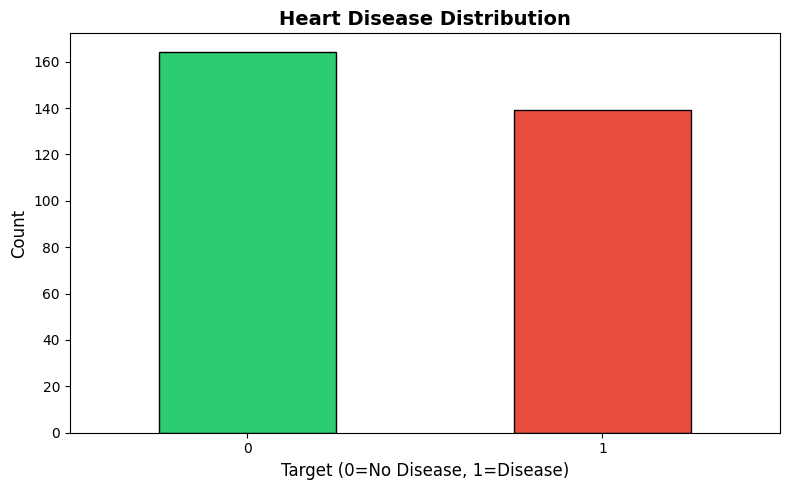

In [34]:
# Target class distribution
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
df['target'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Heart Disease Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Target (0=No Disease, 1=Disease)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

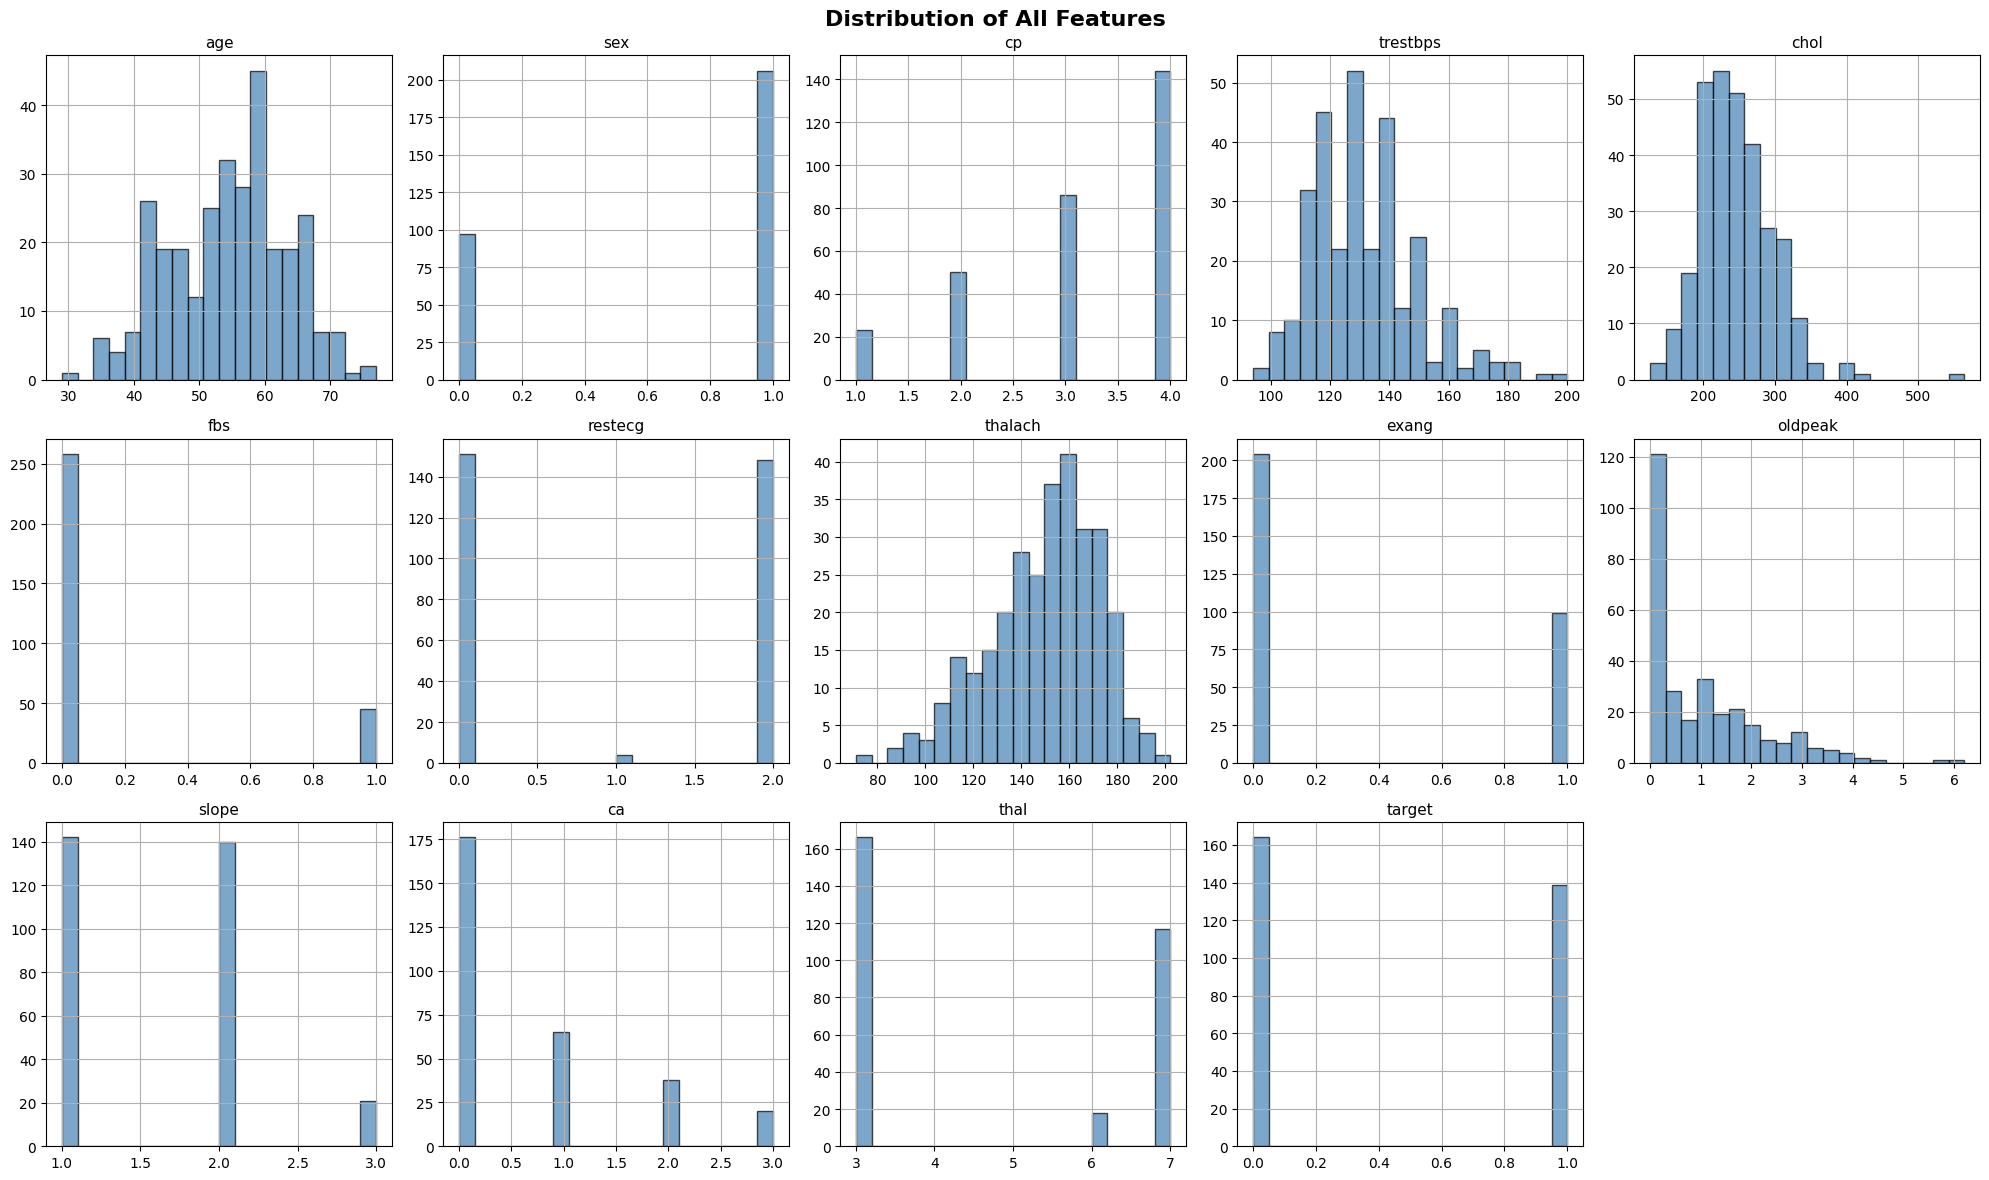

In [35]:
# Distribution of all numerical features
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Distribution of All Features', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    ax = axes[idx // 5, idx % 5]
    df[col].hist(bins=20, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=11)

# Hide the last empty subplot
axes[2, 4].set_visible(False)
plt.tight_layout()
plt.show()

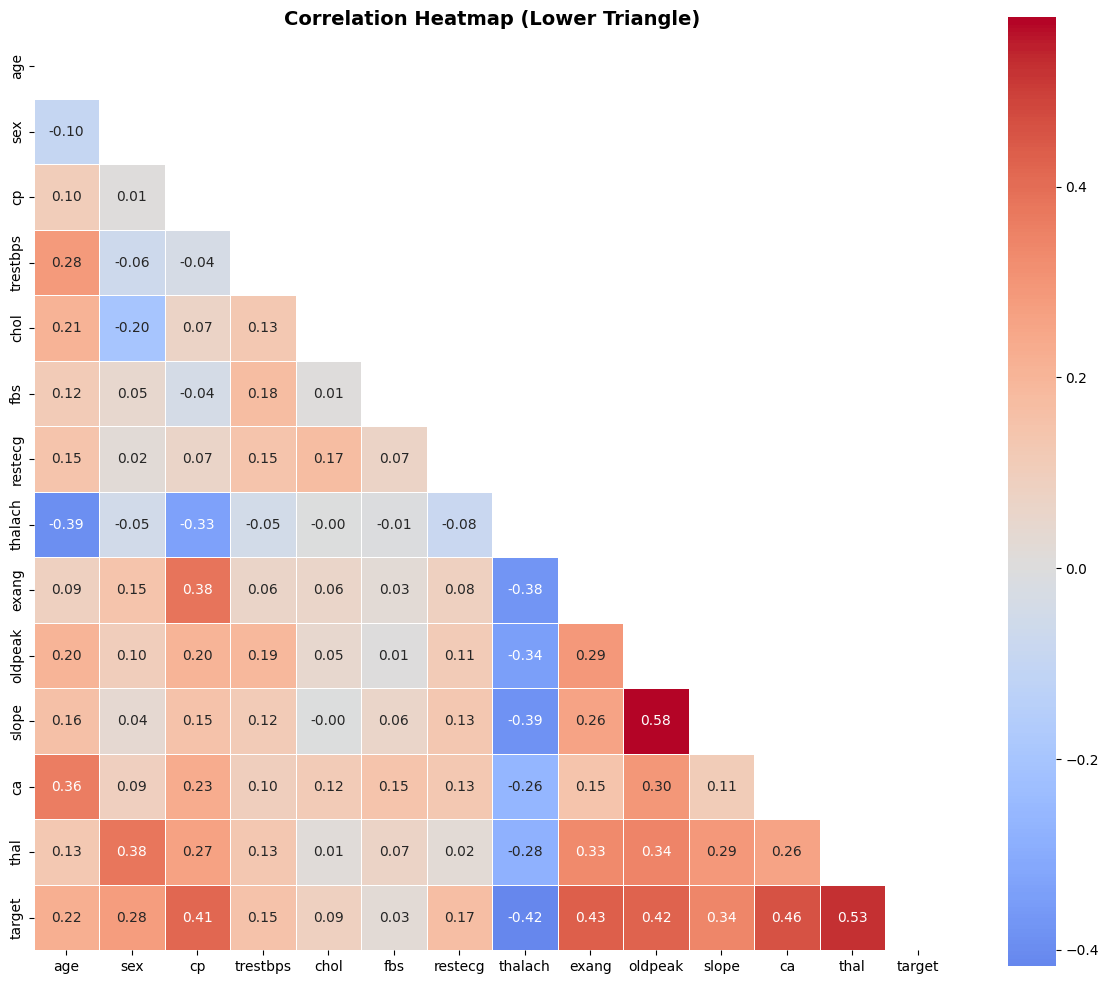

In [36]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.5, square=True, mask=mask)
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

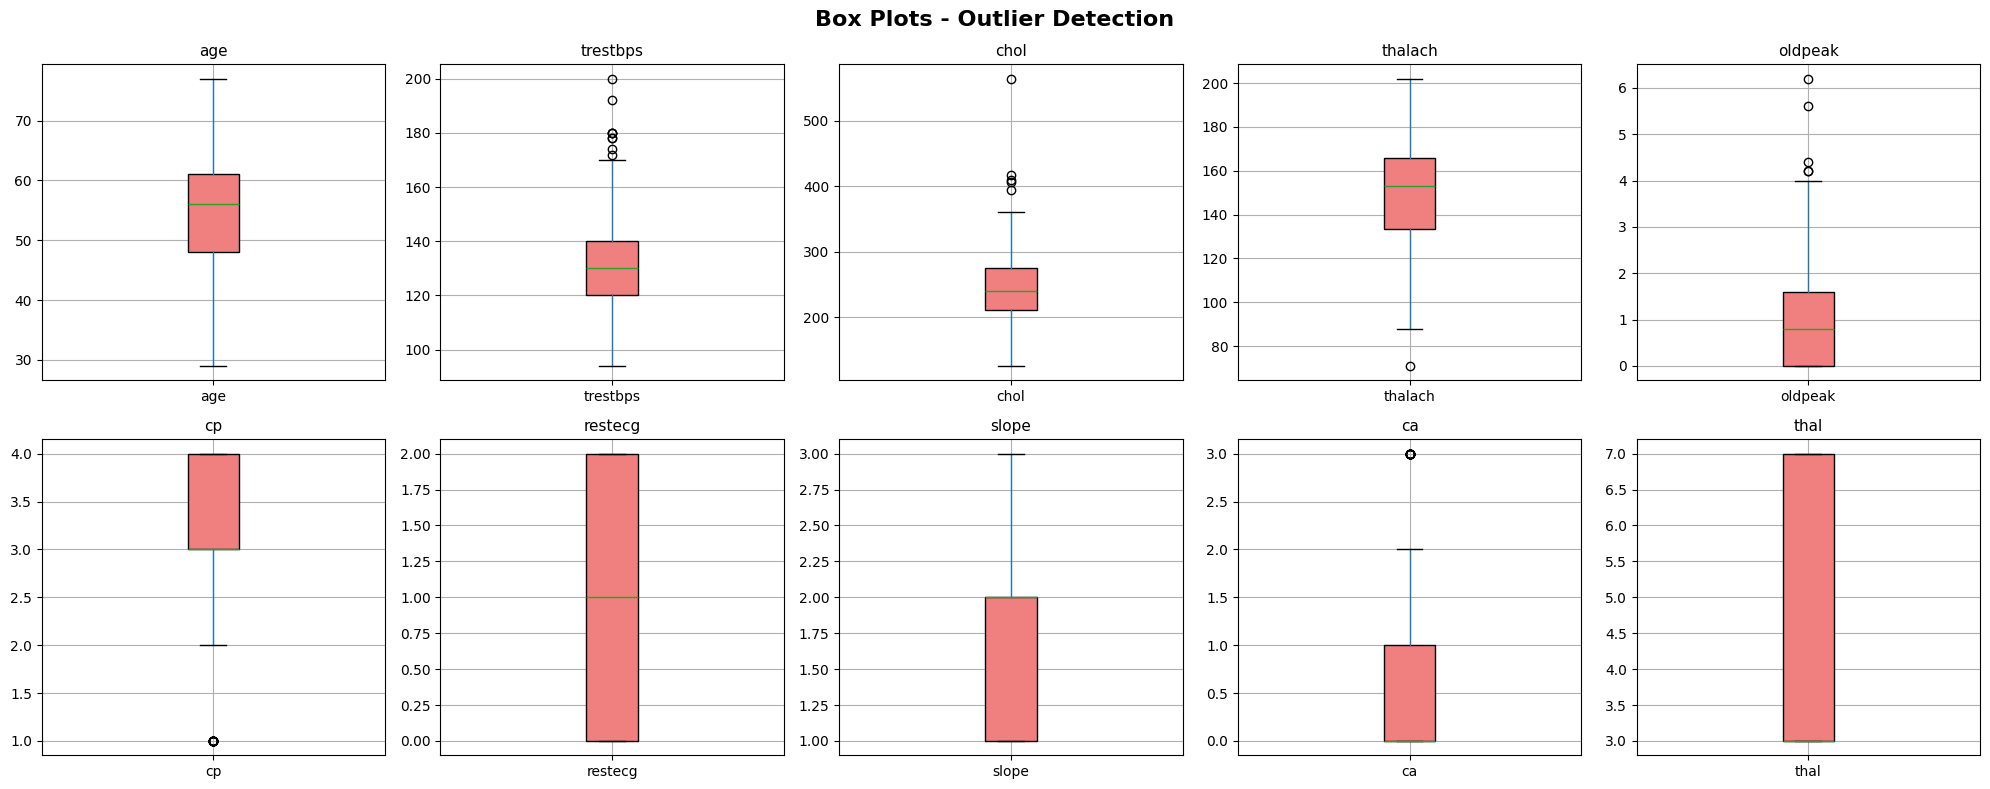

In [37]:
# Box plots to detect outliers
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                   'cp', 'restecg', 'slope', 'ca', 'thal']
for idx, col in enumerate(continuous_cols):
    ax = axes[idx // 5, idx % 5]
    df.boxplot(column=col, ax=ax, patch_artist=True,
               boxprops=dict(facecolor='lightcoral'))
    ax.set_title(col, fontsize=11)

plt.tight_layout()
plt.show()

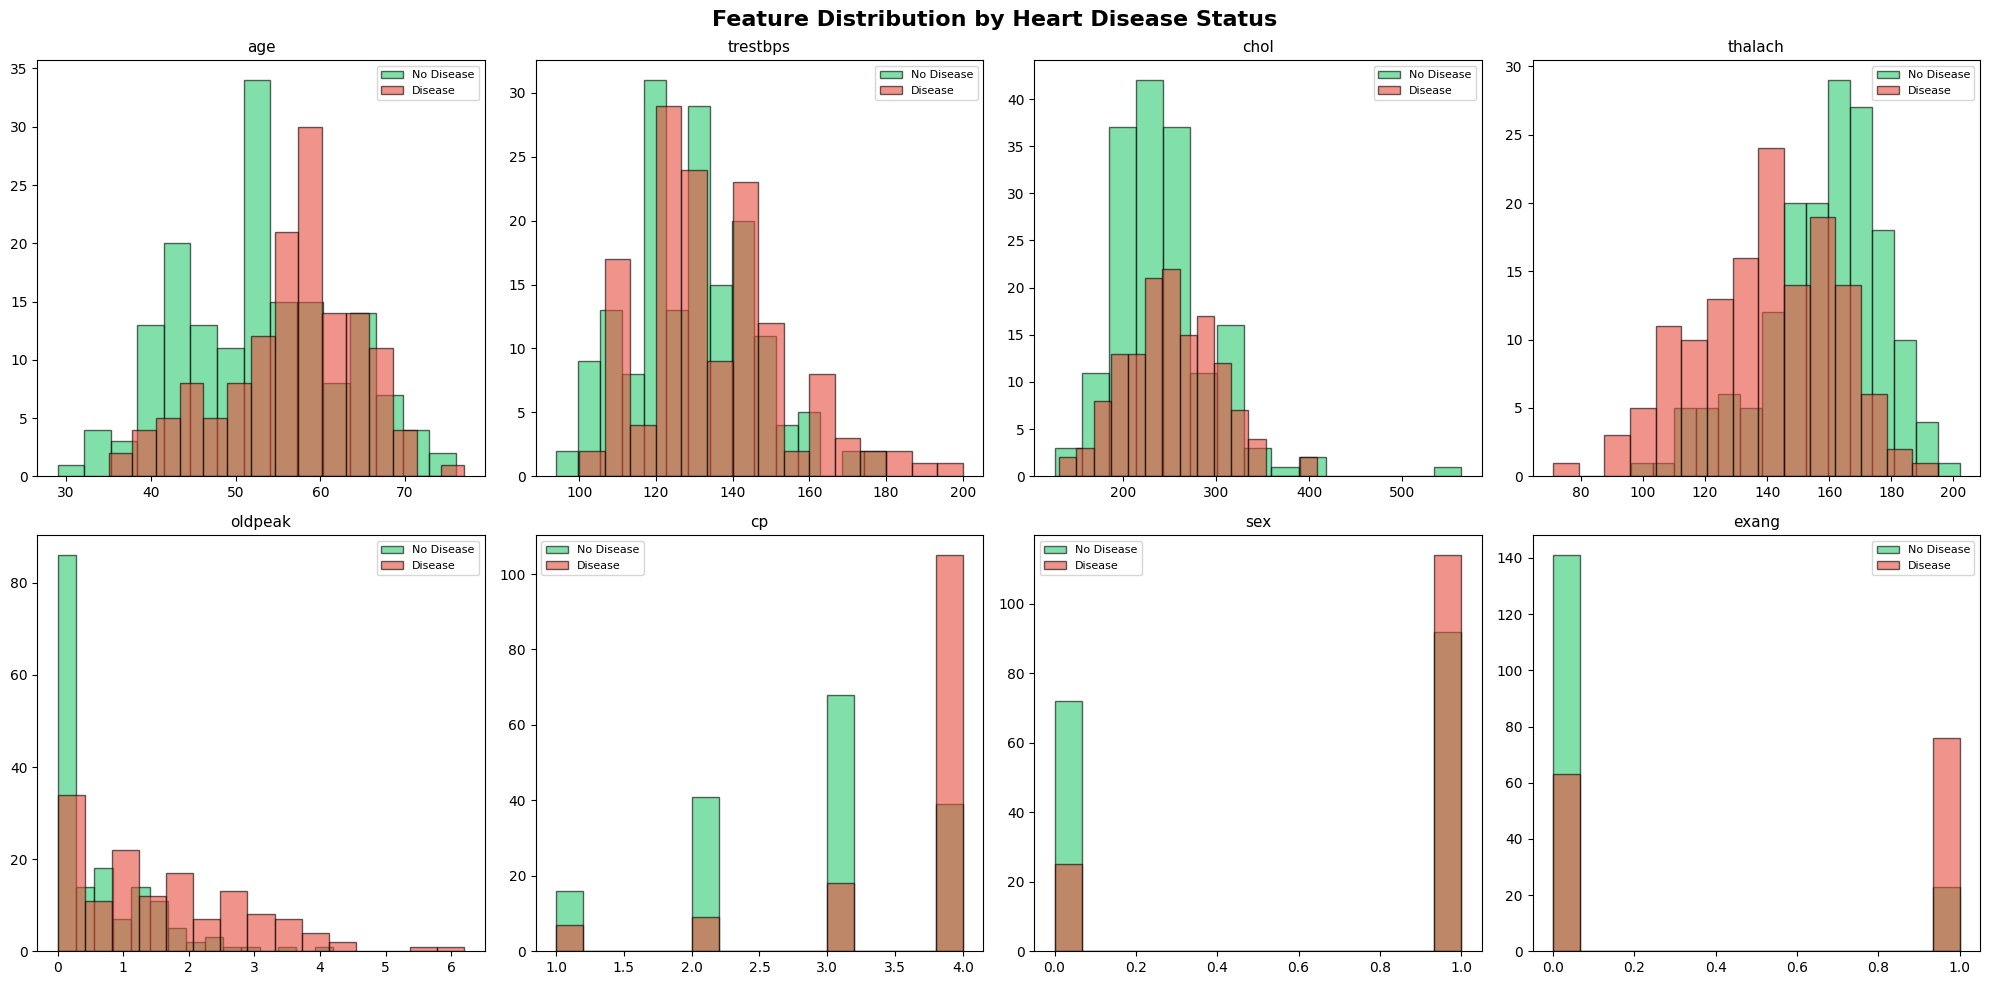

In [38]:
# Feature distribution by target class
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Feature Distribution by Heart Disease Status', fontsize=16, fontweight='bold')

plot_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp', 'sex', 'exang']
for idx, col in enumerate(plot_cols):
    ax = axes[idx // 4, idx % 4]
    for target_val, color, label in [(0, '#2ecc71', 'No Disease'), (1, '#e74c3c', 'Disease')]:
        data = df[df['target'] == target_val][col].dropna()
        ax.hist(data, bins=15, alpha=0.6, color=color, label=label, edgecolor='black')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [39]:
# Handle missing values
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)

print("\nMissing values before handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Fill 'ca' (number of major vessels) with median
df['ca'] = df['ca'].fillna(df['ca'].median())

# Fill 'thal' with mode (most frequent value)
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())
print("\nAll missing values handled successfully!")

HANDLING MISSING VALUES

Missing values before handling:
ca      4
thal    2
dtype: int64

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

All missing values handled successfully!


In [40]:
# Identify categorical and numerical features
print("="*60)
print("FEATURE TYPES IDENTIFICATION")
print("="*60)

# Categorical features (nominal/ordinal)
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
# Numerical (continuous) features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

print(f"\nCategorical Features ({len(categorical_features)}): {categorical_features}")
print(f"Numerical Features ({len(numerical_features)}):   {numerical_features}")

# Show unique values for categorical features
print("\nUnique values in categorical features:")
for col in categorical_features:
    print(f"  {col}: {sorted(df[col].unique())}")

FEATURE TYPES IDENTIFICATION

Categorical Features (7): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
Numerical Features (6):   ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

Unique values in categorical features:
  sex: [np.float64(0.0), np.float64(1.0)]
  cp: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  fbs: [np.float64(0.0), np.float64(1.0)]
  restecg: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
  exang: [np.float64(0.0), np.float64(1.0)]
  slope: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0)]


## 5. Feature and Encoding Techniques

In [41]:
# --- Label Encoding ---
print("="*60)
print("LABEL ENCODING")
print("="*60)

df_label = df.copy()
le = LabelEncoder()

# Apply Label Encoding to categorical features
print("\nLabel Encoding applied to categorical features:")
for col in categorical_features:
    original_values = sorted(df_label[col].unique())
    df_label[col] = le.fit_transform(df_label[col].astype(str))
    encoded_values = sorted(df_label[col].unique())
    print(f"  {col}: {original_values} -> {encoded_values}")

print("\nAfter Label Encoding:")
df_label.head()

LABEL ENCODING

Label Encoding applied to categorical features:
  sex: [np.float64(0.0), np.float64(1.0)] -> [np.int64(0), np.int64(1)]
  cp: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)] -> [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  fbs: [np.float64(0.0), np.float64(1.0)] -> [np.int64(0), np.int64(1)]
  restecg: [np.float64(0.0), np.float64(1.0), np.float64(2.0)] -> [np.int64(0), np.int64(1), np.int64(2)]
  exang: [np.float64(0.0), np.float64(1.0)] -> [np.int64(0), np.int64(1)]
  slope: [np.float64(1.0), np.float64(2.0), np.float64(3.0)] -> [np.int64(0), np.int64(1), np.int64(2)]
  thal: [np.float64(3.0), np.float64(6.0), np.float64(7.0)] -> [np.int64(0), np.int64(1), np.int64(2)]

After Label Encoding:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1,0,145.0,233.0,1,2,150.0,0,2.3,2,0.0,1,0
1,67.0,1,3,160.0,286.0,0,2,108.0,1,1.5,1,3.0,0,1
2,67.0,1,3,120.0,229.0,0,2,129.0,1,2.6,1,2.0,2,1
3,37.0,1,2,130.0,250.0,0,0,187.0,0,3.5,2,0.0,0,0
4,41.0,0,1,130.0,204.0,0,2,172.0,0,1.4,0,0.0,0,0


In [42]:
# --- One-Hot Encoding ---
print("="*60)
print("ONE-HOT ENCODING")
print("="*60)

# Apply One-Hot Encoding to multi-class categorical features
multi_class_cats = ['cp', 'restecg', 'slope', 'thal']  # Features with > 2 unique values
binary_cats = ['sex', 'fbs', 'exang']  # Binary features (already 0/1)

df_onehot = df.copy()
df_onehot = pd.get_dummies(df_onehot, columns=multi_class_cats, prefix=multi_class_cats, drop_first=True)

print(f"\nShape before One-Hot Encoding: {df.shape}")
print(f"Shape after One-Hot Encoding:  {df_onehot.shape}")
print(f"\nNew columns created:")
new_cols = [col for col in df_onehot.columns if any(cat + '_' in col for cat in multi_class_cats)]
print(f"  {new_cols}")
df_onehot.head()

ONE-HOT ENCODING

Shape before One-Hot Encoding: (303, 14)
Shape after One-Hot Encoding:  (303, 19)

New columns created:
  ['cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0']


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,ca,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0,slope_2.0,slope_3.0,thal_6.0,thal_7.0
0,63.0,1.0,145.0,233.0,1.0,150.0,0.0,2.3,0.0,0,False,False,False,False,True,False,True,True,False
1,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,3.0,1,False,False,True,False,True,True,False,False,False
2,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,1,False,False,True,False,True,True,False,False,True
3,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,0.0,0,False,True,False,False,False,False,True,False,False
4,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,0.0,0,True,False,False,False,True,False,False,False,False


In [43]:
# --- Feature Scaling (StandardScaler) ---
print("="*60)
print("FEATURE SCALING (StandardScaler)")
print("="*60)

X = df_onehot.drop('target', axis=1)
y = df_onehot['target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\nBefore Scaling (sample stats):")
print(X[numerical_features].describe().loc[['mean', 'std']].T)
print("\nAfter Scaling (sample stats):")
print(X_scaled[numerical_features].describe().loc[['mean', 'std']].T)

FEATURE SCALING (StandardScaler)

Before Scaling (sample stats):
                mean        std
age        54.438944   9.038662
trestbps  131.689769  17.599748
chol      246.693069  51.776918
thalach   149.607261  22.875003
oldpeak     1.039604   1.161075
ca          0.663366   0.934375

After Scaling (sample stats):
                  mean       std
age      -1.465641e-18  1.001654
trestbps  4.426236e-16  1.001654
chol      2.345026e-16  1.001654
thalach  -1.172513e-16  1.001654
oldpeak   2.345026e-17  1.001654
ca       -4.690051e-17  1.001654


## 6. Feature Selection

METHOD 1: CORRELATION-BASED FEATURE SELECTION

Correlation of features with target (|r|):
cp_4.0         0.516459
thal_7.0       0.480582
ca             0.460033
exang          0.431894
oldpeak        0.424510
thalach        0.417167
slope_2.0      0.355709
cp_3.0         0.315141
sex            0.276816
cp_2.0         0.248683
age            0.223120
restecg_2.0    0.160400
trestbps       0.150825
thal_6.0       0.104864
chol           0.085164
restecg_1.0    0.067605
slope_3.0      0.061710
fbs            0.025264
Name: target, dtype: float64


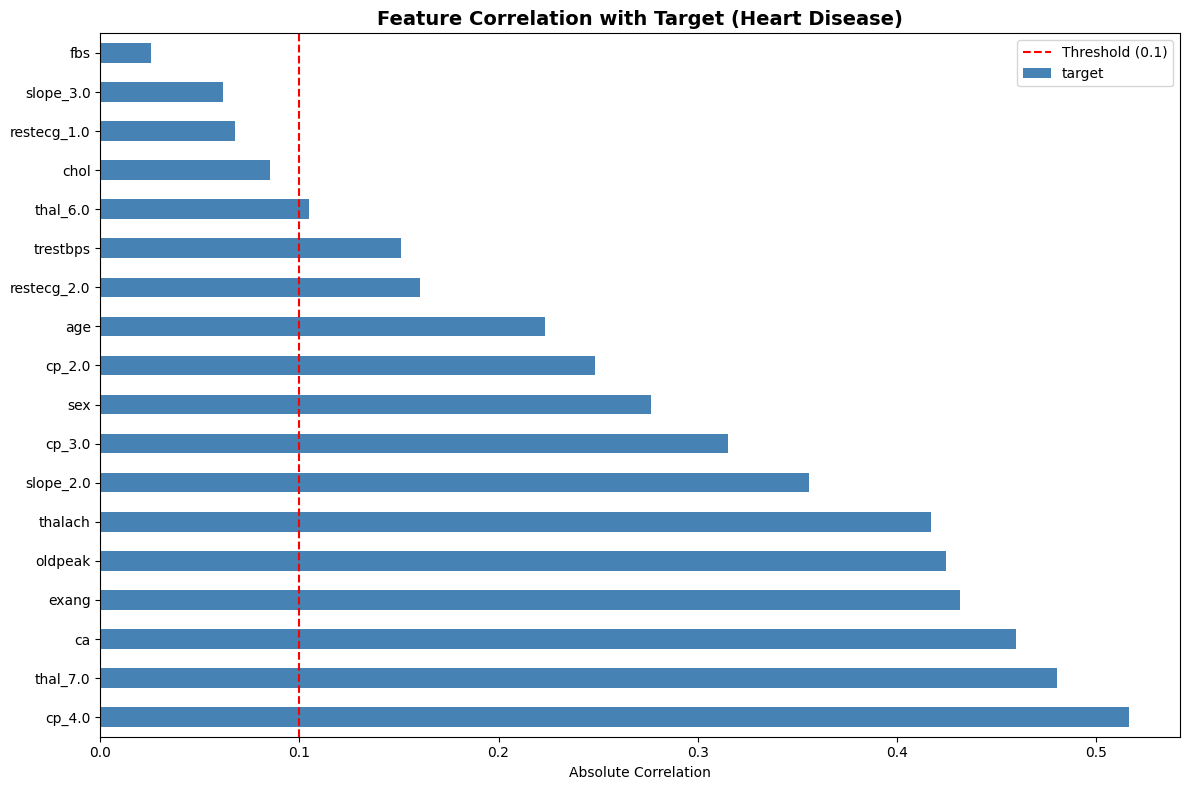

In [44]:
# --- Method 1: Correlation-based Feature Selection ---
print("="*60)
print("METHOD 1: CORRELATION-BASED FEATURE SELECTION")
print("="*60)

correlation_with_target = df_onehot.corr()['target'].drop('target').abs().sort_values(ascending=False)
print("\nCorrelation of features with target (|r|):")
print(correlation_with_target)

# Visualize
plt.figure(figsize=(12, 8))
correlation_with_target.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Target (Heart Disease)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold (0.1)')
plt.legend()
plt.tight_layout()
plt.show()

METHOD 2: MUTUAL INFORMATION FEATURE SELECTION

Mutual Information Scores:
thal_7.0       0.139400
cp_4.0         0.134514
oldpeak        0.099448
thalach        0.080807
ca             0.079527
chol           0.073596
sex            0.066975
exang          0.062070
slope_2.0      0.052551
thal_6.0       0.043504
restecg_2.0    0.042042
fbs            0.037382
age            0.001320
trestbps       0.000000
cp_2.0         0.000000
cp_3.0         0.000000
restecg_1.0    0.000000
slope_3.0      0.000000
dtype: float64


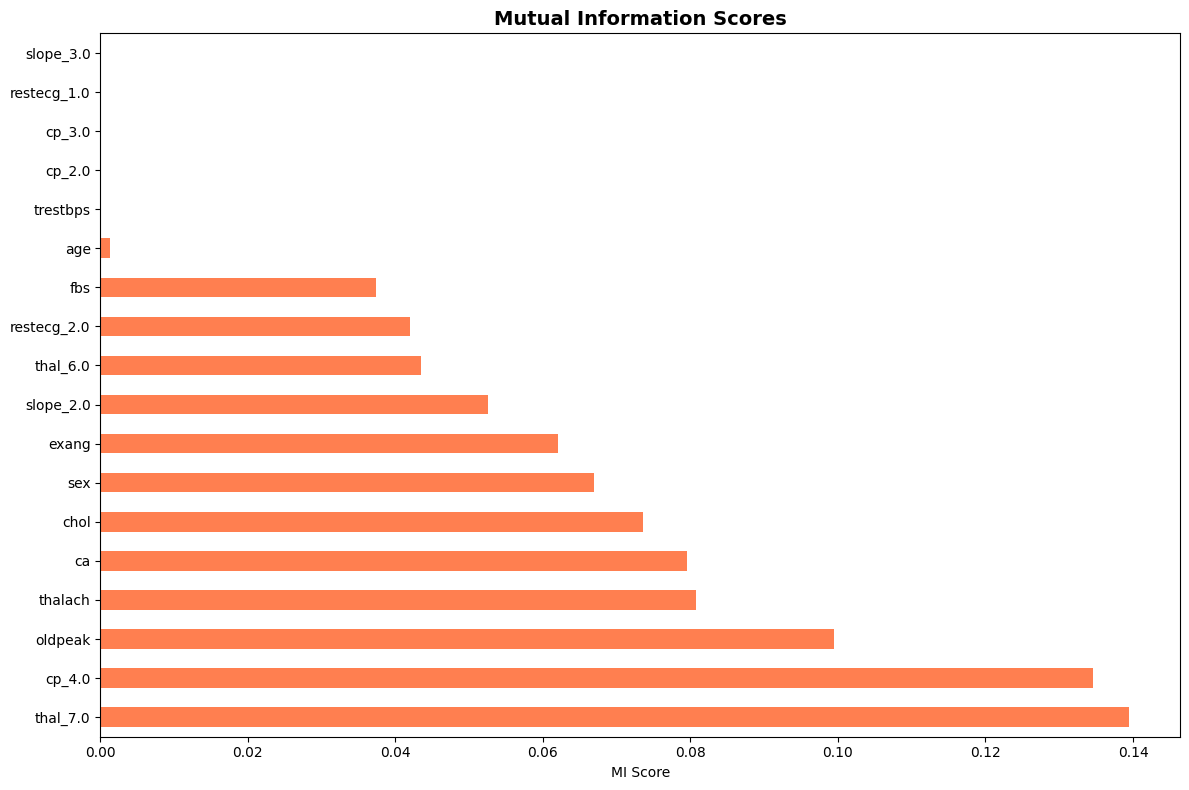

In [45]:
# --- Method 2: Mutual Information ---
print("="*60)
print("METHOD 2: MUTUAL INFORMATION FEATURE SELECTION")
print("="*60)

mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("\nMutual Information Scores:")
print(mi_series)

plt.figure(figsize=(12, 8))
mi_series.plot(kind='barh', color='coral')
plt.title('Mutual Information Scores', fontsize=14, fontweight='bold')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

METHOD 3: SelectKBest (chi2)

Chi-Squared Scores:
thal_7.0       42.958360
cp_4.0         42.410097
exang          38.052613
ca             28.038394
cp_3.0         21.551109
slope_2.0      20.624160
cp_2.0         15.646367
oldpeak        11.382669
sex             7.432845
restecg_2.0     3.987845
thal_6.0        3.133971
thalach         2.670638
restecg_1.0     1.366567
slope_3.0       1.073891
age             1.005896
trestbps        0.532647
fbs             0.164669
chol            0.111079
dtype: float64

Top 8 Selected Features: ['exang', 'oldpeak', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7.0']


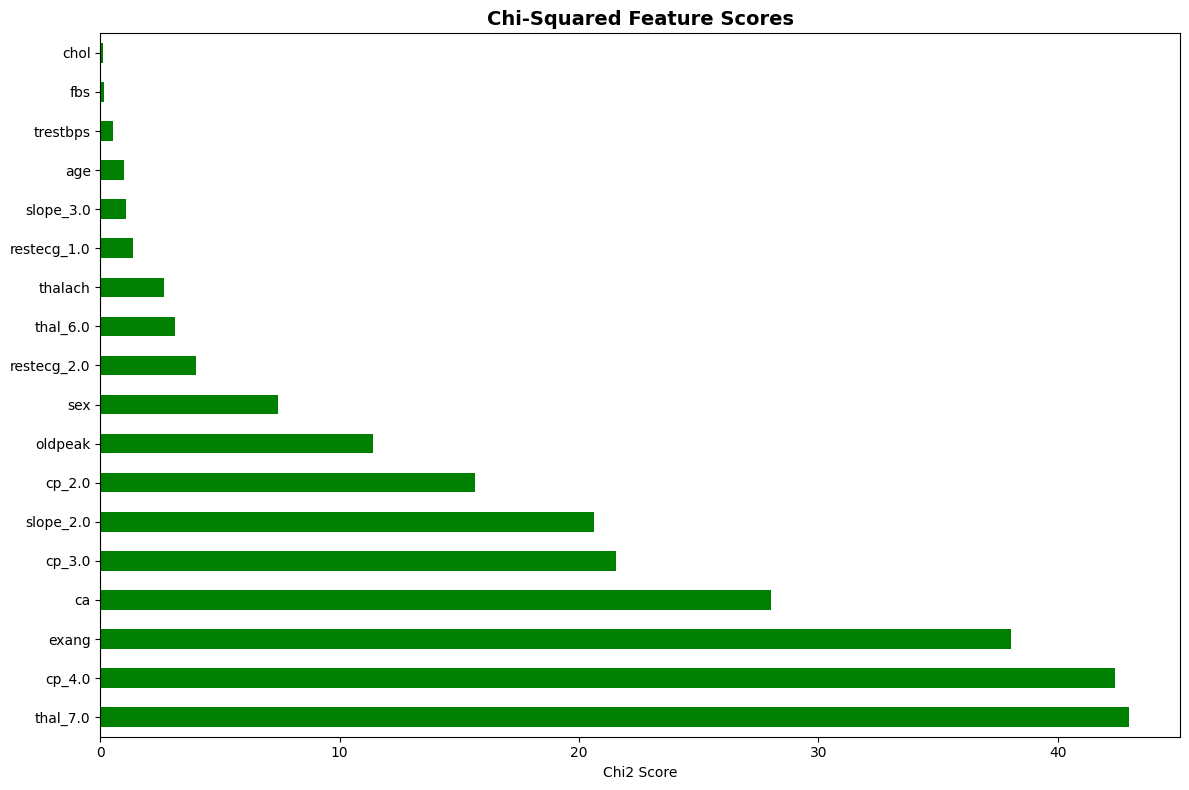

In [46]:
# --- Method 3: SelectKBest with chi2 ---
print("="*60)
print("METHOD 3: SelectKBest (chi2)")
print("="*60)

# chi2 requires non-negative features
X_minmax = MinMaxScaler().fit_transform(X)

selector = SelectKBest(chi2, k=8)
X_selected = selector.fit_transform(X_minmax, y)

chi2_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print("\nChi-Squared Scores:")
print(chi2_scores)

selected_features = X.columns[selector.get_support()].tolist()
print(f"\nTop 8 Selected Features: {selected_features}")

plt.figure(figsize=(12, 8))
chi2_scores.plot(kind='barh', color='green')
plt.title('Chi-Squared Feature Scores', fontsize=14, fontweight='bold')
plt.xlabel('Chi2 Score')
plt.tight_layout()
plt.show()

## 7. Build Logistic Regression Model

In [47]:
# Train-Test Split
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts()}")

TRAIN-TEST SPLIT
Training set size: 242
Testing set size:  61

Training set class distribution:
target
0    131
1    111
Name: count, dtype: int64

Testing set class distribution:
target
0    33
1    28
Name: count, dtype: int64


In [48]:
# Build the Logistic Regression Model (All Features)
print("="*60)
print("LOGISTIC REGRESSION MODEL (ALL FEATURES)")
print("="*60)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("\nModel trained successfully!")
print(f"\nModel Coefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

LOGISTIC REGRESSION MODEL (ALL FEATURES)

Model trained successfully!

Model Coefficients:
    Feature  Coefficient
         ca     1.211742
     cp_4.0     0.869378
        sex     0.737926
   thal_7.0     0.678764
  slope_2.0     0.596544
   trestbps     0.352032
     cp_2.0     0.333273
      exang     0.272780
    oldpeak     0.200290
restecg_2.0     0.199589
       chol     0.197743
  slope_3.0     0.074475
     cp_3.0     0.065440
   thal_6.0     0.020994
        age    -0.063762
        fbs    -0.089273
restecg_1.0    -0.144978
    thalach    -0.360040

Intercept: -0.0266


## 8. Model Evaluation

In [49]:
# --- Accuracy & Classification Report ---
print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Disease (1)']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

MODEL EVALUATION METRICS

Accuracy: 0.8525 (85.25%)

CLASSIFICATION REPORT
                precision    recall  f1-score   support

No Disease (0)       0.90      0.82      0.86        33
   Disease (1)       0.81      0.89      0.85        28

      accuracy                           0.85        61
     macro avg       0.85      0.86      0.85        61
  weighted avg       0.86      0.85      0.85        61

ROC-AUC Score: 0.9470


CONFUSION MATRIX


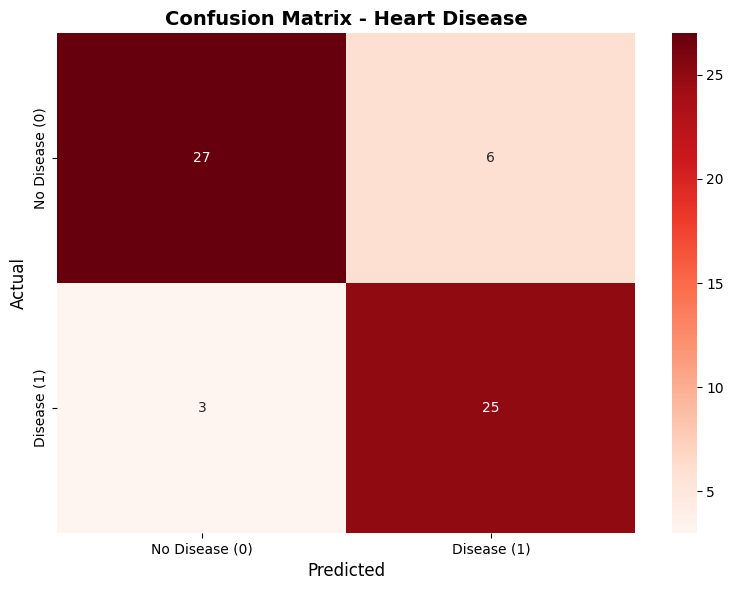


True Negatives (correctly predicted No Disease):  27
False Positives (incorrectly predicted Disease):   6
False Negatives (missed Disease cases):            3
True Positives (correctly predicted Disease):      25


In [50]:
# --- Confusion Matrix ---
print("="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Heart Disease', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives (correctly predicted No Disease):  {cm[0][0]}")
print(f"False Positives (incorrectly predicted Disease):   {cm[0][1]}")
print(f"False Negatives (missed Disease cases):            {cm[1][0]}")
print(f"True Positives (correctly predicted Disease):      {cm[1][1]}")

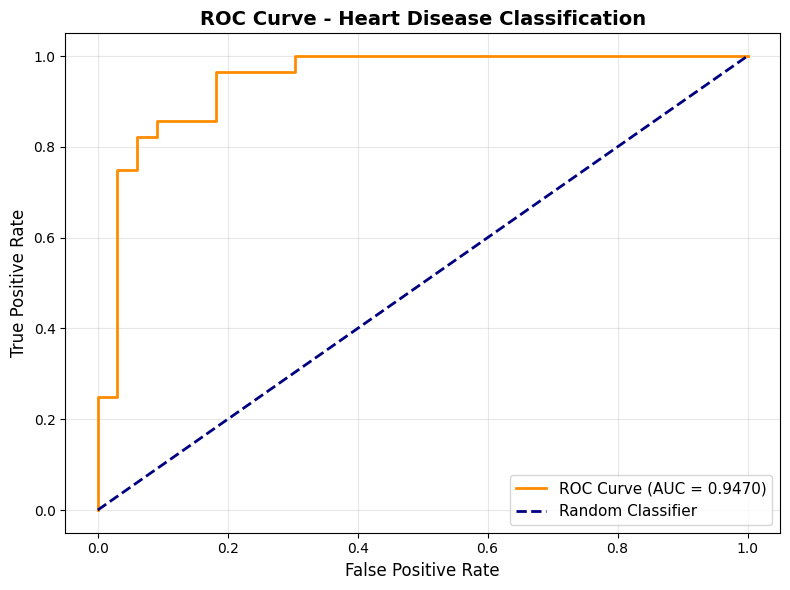

In [51]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Heart Disease Classification', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

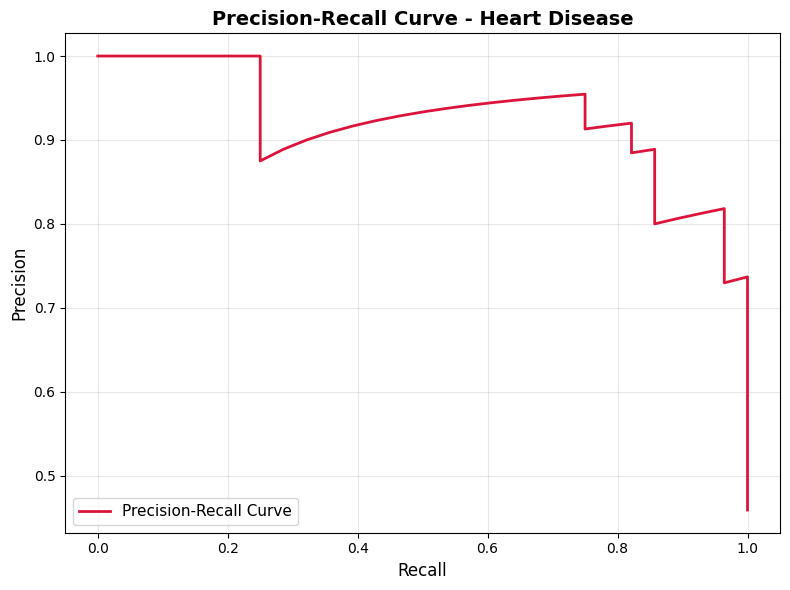

In [52]:
# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='crimson', lw=2, label='Precision-Recall Curve')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Heart Disease', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

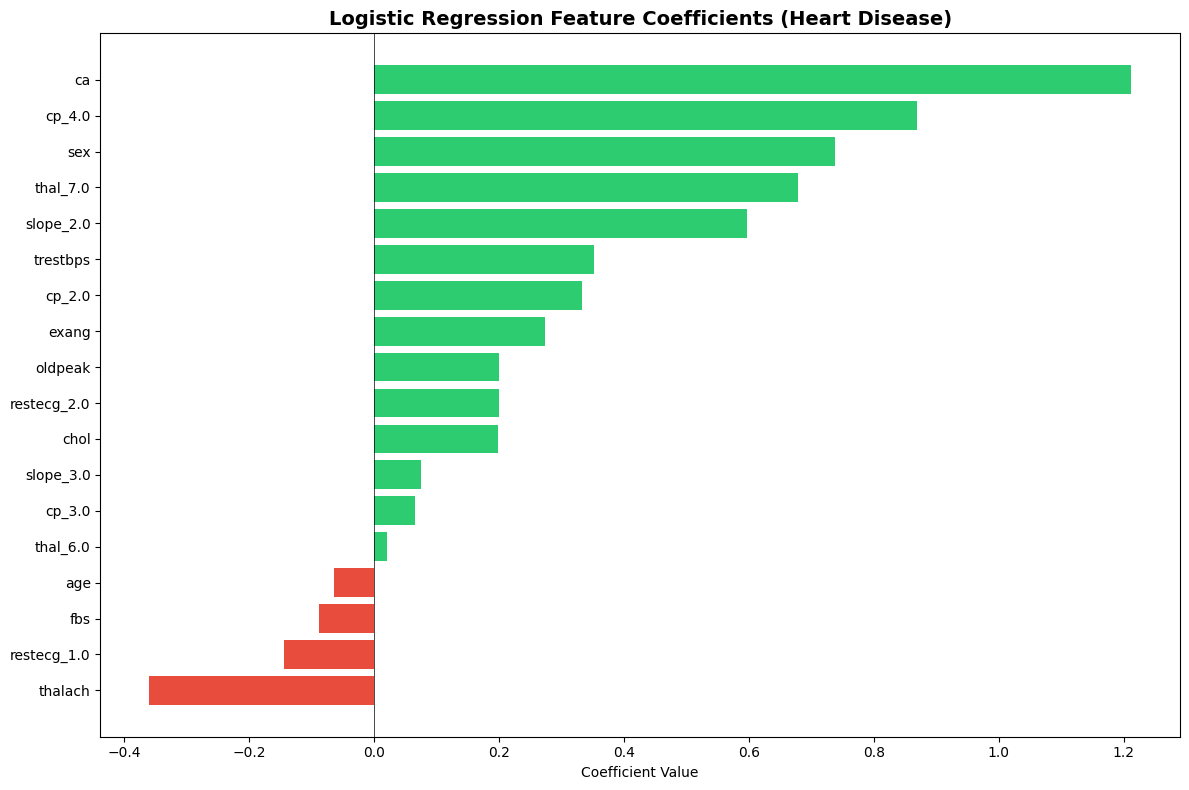

Green = Positive coefficient (increases probability of disease)
Red   = Negative coefficient (decreases probability of disease)


In [53]:
# --- Feature Importance (Coefficient Magnitude) ---
plt.figure(figsize=(12, 8))
coef_df_sorted = coef_df.sort_values('Coefficient')
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df_sorted['Coefficient']]
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.title('Logistic Regression Feature Coefficients (Heart Disease)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

print("Green = Positive coefficient (increases probability of disease)")
print("Red   = Negative coefficient (decreases probability of disease)")

## 9. Model with Selected Features

In [54]:
# Build model using selected features from SelectKBest
print("="*60)
print("LOGISTIC REGRESSION WITH SELECTED FEATURES")
print("="*60)

print(f"\nUsing top 8 features: {selected_features}")

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

log_reg_sel = LogisticRegression(max_iter=1000, random_state=42)
log_reg_sel.fit(X_train_sel, y_train)

y_pred_sel = log_reg_sel.predict(X_test_sel)
y_pred_proba_sel = log_reg_sel.predict_proba(X_test_sel)[:, 1]

accuracy_sel = accuracy_score(y_test, y_pred_sel)
roc_auc_sel = roc_auc_score(y_test, y_pred_proba_sel)

print(f"\nAccuracy (Selected Features): {accuracy_sel:.4f} ({accuracy_sel*100:.2f}%)")
print(f"ROC-AUC (Selected Features):  {roc_auc_sel:.4f}")

print("\nClassification Report (Selected Features):")
print(classification_report(y_test, y_pred_sel, target_names=['No Disease (0)', 'Disease (1)']))

LOGISTIC REGRESSION WITH SELECTED FEATURES

Using top 8 features: ['exang', 'oldpeak', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'slope_2.0', 'thal_7.0']

Accuracy (Selected Features): 0.8689 (86.89%)
ROC-AUC (Selected Features):  0.9481

Classification Report (Selected Features):
                precision    recall  f1-score   support

No Disease (0)       0.90      0.85      0.88        33
   Disease (1)       0.83      0.89      0.86        28

      accuracy                           0.87        61
     macro avg       0.87      0.87      0.87        61
  weighted avg       0.87      0.87      0.87        61



In [55]:
# --- Comparison ---
print("="*60)
print("MODEL COMPARISON: ALL FEATURES vs SELECTED FEATURES")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC Score', 'Number of Features'],
    'All Features': [f'{accuracy:.4f}', f'{roc_auc:.4f}', X.shape[1]],
    'Selected Features (Top 8)': [f'{accuracy_sel:.4f}', f'{roc_auc_sel:.4f}', len(selected_features)]
})
print("\n")
print(comparison.to_string(index=False))

MODEL COMPARISON: ALL FEATURES vs SELECTED FEATURES


            Metric All Features Selected Features (Top 8)
          Accuracy       0.8525                    0.8689
     ROC-AUC Score       0.9470                    0.9481
Number of Features           18                         8


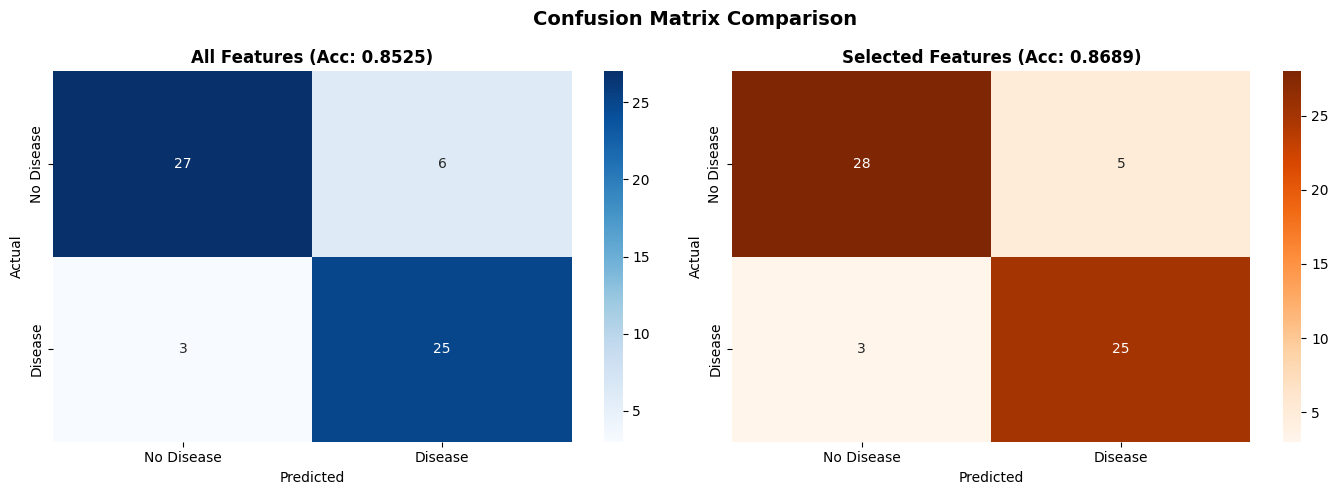

In [56]:
# Confusion Matrix comparison side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_all = confusion_matrix(y_test, y_pred)
cm_sel = confusion_matrix(y_test, y_pred_sel)

sns.heatmap(cm_all, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title(f'All Features (Acc: {accuracy:.4f})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(cm_sel, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[1].set_title(f'Selected Features (Acc: {accuracy_sel:.4f})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Conclusion

### Summary:
1. **Data Statistics**: Explored the Cleveland Heart Disease dataset with 303 instances and 14 attributes. Found missing values in `ca` (4) and `thal` (2) columns.
2. **Preprocessing**: Handled missing values (median for `ca`, mode for `thal`). Converted multi-class target (0-4) to binary (0 vs 1-4).
3. **Encoding Techniques**:
   - **Label Encoding**: Applied to all categorical features for numerical representation.
   - **One-Hot Encoding**: Applied to multi-class categorical features (`cp`, `restecg`, `slope`, `thal`) with `drop_first=True`.
4. **Feature Scaling**: Applied StandardScaler to normalize all features.
5. **Feature Selection**: Used three methods:
   - Correlation analysis with target
   - Mutual Information scores
   - Chi-Squared test (SelectKBest)
6. **Logistic Regression Model**: Built with all features and selected features (top 8).
7. **Evaluation Metrics**: Accuracy, Classification Report, Confusion Matrix, ROC-AUC, ROC Curve, and Precision-Recall Curve.

### Key Findings:
- **Important features** for predicting heart disease include: `thal`, `cp`, `ca`, `oldpeak`, `exang`, `thalach`, and `sex`.
- Feature selection can maintain competitive accuracy while reducing model complexity.

---